# CNN Development on Custom Dataset

## Student Information

**Name:** SAISHAB SARKAR

**Student ID:** 23-55011-3

**Course:** Computer Vision and Pattern Recognition (CVPR)

**Assignment:** CNN Development on Custom Dataset

**Dataset:** Indian Flower Seed Dataset (40 Classes-10444 images)-mendeley- published 8 Jul 2026

---

## Objective

The objective of this assignment is to develop a custom Convolutional Neural Network (CNN) capable of classifying Indian flower seed images into their respective classes. The model will be trained using PyTorch and evaluated using accuracy, precision, recall, F1-score, confusion matrix, and loss/accuracy curves.

#  Import Libraries


In [38]:
# ============================================
# Import Required Libraries
# ============================================

import os
import random
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Set plotting style
plt.style.use("ggplot")

print("All libraries imported successfully.")

All libraries imported successfully.


#  Check GPU Availability



In [39]:
# ============================================
# Check GPU
# ============================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

Using Device: cuda
GPU Name: Tesla T4


#  Mount Google Drive



In [40]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
import os

dataset_path = "/content/drive/MyDrive/CVPR_Assignment/Dataset1"

print("Dataset exists:", os.path.exists(dataset_path))

folders = sorted(os.listdir(dataset_path))

print("Number of folders:", len(folders))

print("\nFirst 10 folders:")
for folder in folders[:10]:
    print(folder)

Dataset exists: True
Number of folders: 40

First 10 folders:
AFRICAN MARGOLD
ALYSSUM
Acroclineum
CALENDULA
CHRYSANTHEMUM
COREOPSIS
DIMORPHOTHECA
Dahlia
GOMPHRENA MIX
GYPSOPHILA


In [42]:
import os

for folder in sorted(os.listdir(dataset_path)):
    path = os.path.join(dataset_path, folder)

    if os.path.isdir(path):
        num_images = len(os.listdir(path))
        print(f"{folder:25s} -> {num_images}")

AFRICAN MARGOLD           -> 267
ALYSSUM                   -> 308
Acroclineum               -> 200
CALENDULA                 -> 265
CHRYSANTHEMUM             -> 262
COREOPSIS                 -> 287
DIMORPHOTHECA             -> 256
Dahlia                    -> 280
GOMPHRENA MIX             -> 252
GYPSOPHILA                -> 284
Gaillardia                -> 255
HELICHRYSUM               -> 155
HOLLYHOCK                 -> 254
Ice Flower                -> 260
Lupins                    -> 260
MORNING GLORY             -> 261
NASTURIUM                 -> 256
NEMOPHILA                 -> 288
Nemesia                   -> 280
PANSY DBL MIX             -> 172
PHLOX                     -> 250
SALVIA                    -> 251
SUNFLOWER DWARF           -> 293
SUNFLOWER TALL            -> 269
SWEET WILLIAM             -> 340
Stock(Matthiola)          -> 260
ZINNIA                    -> 278
calliopsis                -> 260
candytuft                 -> 260
celosia pulmosa           -> 240
cherinathu



# Remove .DS_Store


In [43]:
import os

ds_store = os.path.join(dataset_path, ".DS_Store")

if os.path.exists(ds_store):
    os.remove(ds_store)
    print(".DS_Store removed successfully.")
else:
    print("No .DS_Store found.")

No .DS_Store found.


In [44]:
print(len(os.listdir(dataset_path)))
print(sorted(os.listdir(dataset_path))[:5])

40
['AFRICAN MARGOLD', 'ALYSSUM', 'Acroclineum', 'CALENDULA', 'CHRYSANTHEMUM']


# 3. Load and Explore Dataset

The dataset is loaded using PyTorch's `ImageFolder` class. Each folder represents a separate flower seed category. Images are resized to 128×128 pixels and converted into tensors before training.

In [45]:
from torchvision import datasets, transforms

# Basic Transform
basic_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# Load Dataset
full_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=basic_transform
)

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [46]:
print("="*60)
print("Dataset Summary")
print("="*60)

print(f"Number of Classes : {len(full_dataset.classes)}")
print(f"Total Images      : {len(full_dataset)}")

print("\nFirst 10 Classes\n")

for i, class_name in enumerate(full_dataset.classes[:10]):
    print(f"{i+1}. {class_name}")

Dataset Summary
Number of Classes : 40
Total Images      : 10452

First 10 Classes

1. AFRICAN MARGOLD
2. ALYSSUM
3. Acroclineum
4. CALENDULA
5. CHRYSANTHEMUM
6. COREOPSIS
7. DIMORPHOTHECA
8. Dahlia
9. GOMPHRENA MIX
10. GYPSOPHILA


## Visualizing Sample Images

To better understand the dataset, a few sample images are displayed with their corresponding class labels.

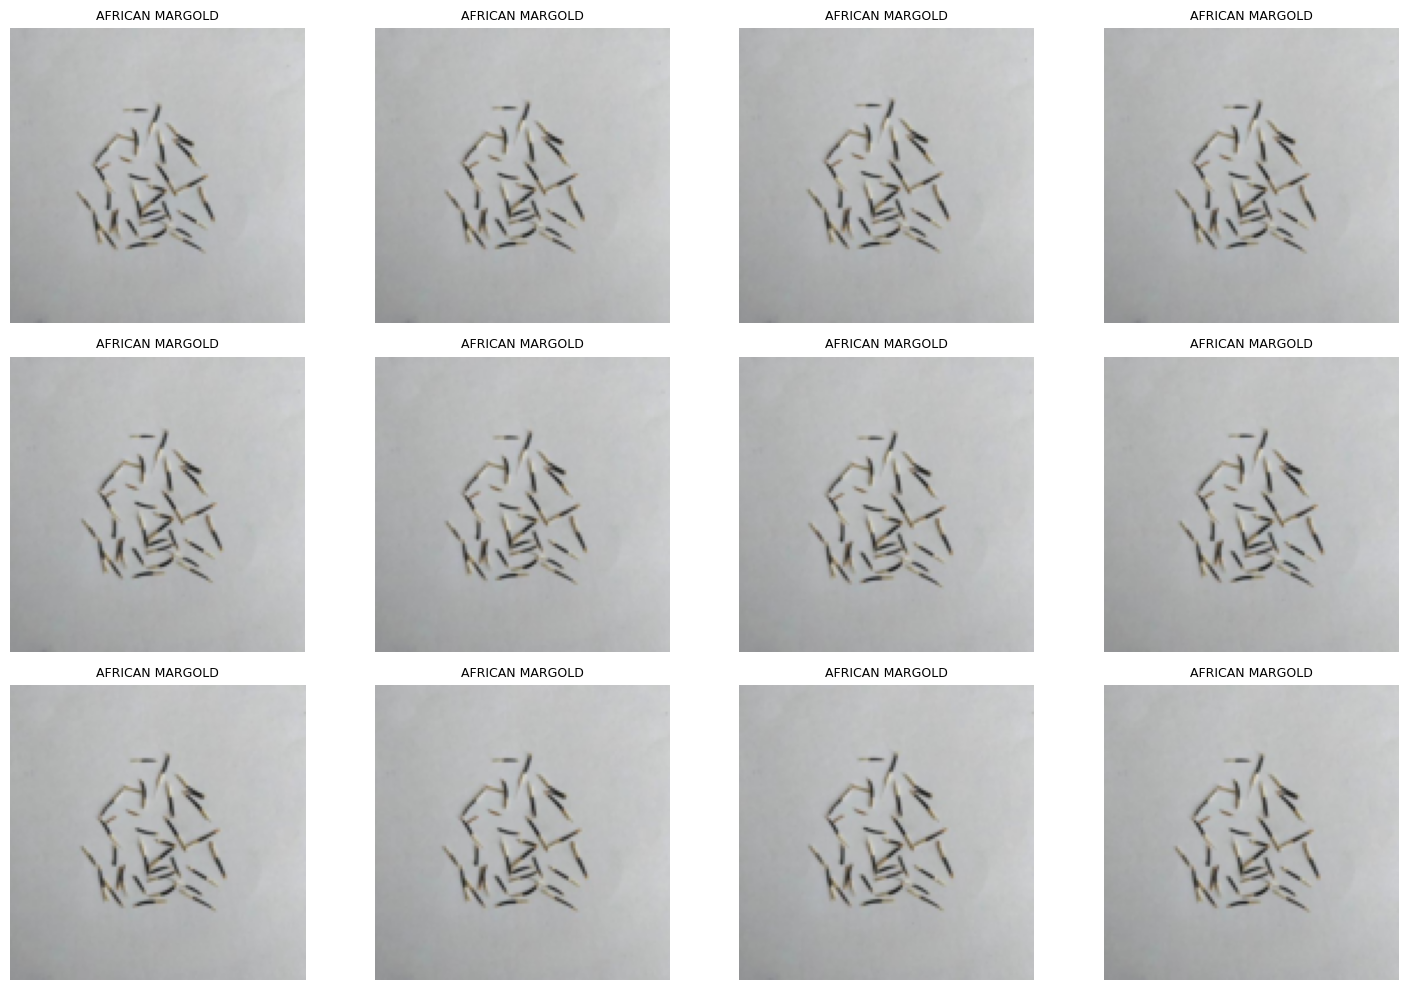

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

for i in range(12):

    image, label = full_dataset[i]

    plt.subplot(3,4,i+1)

    plt.imshow(image.permute(1,2,0))

    plt.title(full_dataset.classes[label], fontsize=9)

    plt.axis("off")

plt.tight_layout()
plt.show()

In [48]:
from collections import Counter
import pandas as pd

labels = [label for _, label in full_dataset.samples]

counter = Counter(labels)

class_counts = pd.DataFrame({
    "Class": full_dataset.classes,
    "Images": [counter[i] for i in range(len(full_dataset.classes))]
})

class_counts

,Class,Images
0,AFRICAN MARGOLD,267
1,ALYSSUM,308
2,Acroclineum,200
3,CALENDULA,265
4,CHRYSANTHEMUM,262
5,COREOPSIS,287
6,DIMORPHOTHECA,256
7,Dahlia,280
8,GOMPHRENA MIX,252
9,GYPSOPHILA,284


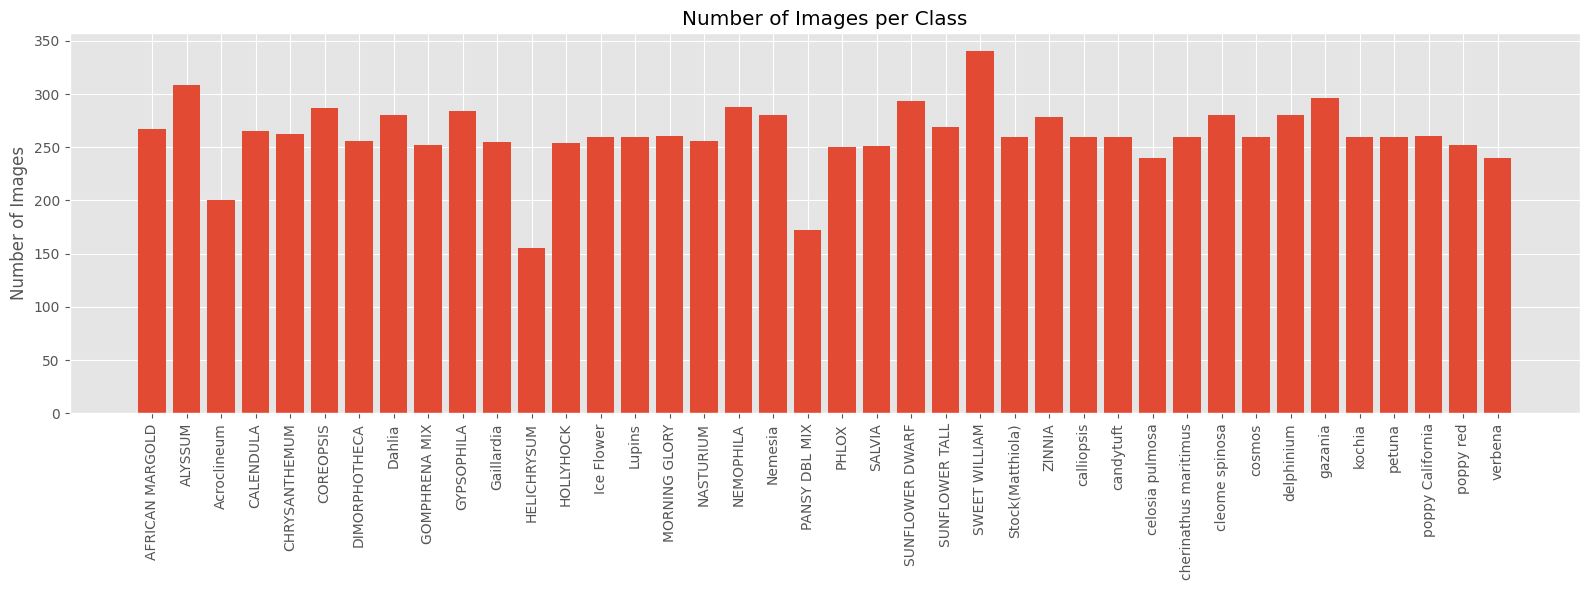

In [49]:
plt.figure(figsize=(16,6))

plt.bar(class_counts["Class"], class_counts["Images"])

plt.xticks(rotation=90)

plt.ylabel("Number of Images")

plt.title("Number of Images per Class")

plt.tight_layout()

plt.show()

# 4. Data Preprocessing & Data Augmentation

Data preprocessing prepares images for training by resizing and normalizing them. Data augmentation is applied only to the training dataset to improve model generalization and reduce overfitting.

In [50]:
# ============================================
# Data Preprocessing & Augmentation
# ============================================

from torchvision import transforms

# Training Transform
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation/Test Transform
test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms Created Successfully.")

Transforms Created Successfully.


# 5. Split Dataset

The dataset is divided into training, validation, and testing subsets using a 70:15:15 ratio.

In [51]:
from torch.utils.data import random_split

# Dataset Size
dataset_size = len(full_dataset)

train_size = int(0.70 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Training Images :", len(train_dataset))
print("Validation Images :", len(val_dataset))
print("Testing Images :", len(test_dataset))

Training Images : 7316
Validation Images : 1567
Testing Images : 1569


# 6. Create Dataset Splits

The dataset is first loaded without any transformation. After splitting into training, validation, and testing subsets, different transformations are applied to each subset. This ensures that data augmentation is used only during training while validation and testing remain unchanged.

In [52]:
# ============================================
# Load Dataset Without Transform
# ============================================

from torchvision.datasets import ImageFolder

base_dataset = ImageFolder(
    root=dataset_path,
    transform=None
)

print("Dataset Loaded Successfully!")
print("Classes :", len(base_dataset.classes))
print("Images :", len(base_dataset))

Dataset Loaded Successfully!
Classes : 40
Images : 10452


In [53]:
from torch.utils.data import random_split

dataset_size = len(base_dataset)

train_size = int(0.70 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    base_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("="*50)

print("Training Images :", len(train_dataset))
print("Validation Images :", len(val_dataset))
print("Testing Images :", len(test_dataset))

print("="*50)

Training Images : 7316
Validation Images : 1567
Testing Images : 1569


In [54]:
# ============================================
# Dataset Wrapper
# ============================================

from torch.utils.data import Dataset

class TransformDataset(Dataset):

    def __init__(self, subset, transform=None):

        self.subset = subset
        self.transform = transform

    def __len__(self):

        return len(self.subset)

    def __getitem__(self, index):

        image, label = self.subset[index]

        if self.transform:
            image = self.transform(image)

        return image, label

In [55]:
train_dataset = TransformDataset(
    train_dataset,
    transform=train_transform
)

val_dataset = TransformDataset(
    val_dataset,
    transform=test_transform
)

test_dataset = TransformDataset(
    test_dataset,
    transform=test_transform
)

# 7. Create DataLoaders

DataLoaders are used to efficiently load the dataset during training, validation, and testing. Training data is shuffled to improve learning, while validation and testing data remain in a fixed order.

In [56]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("="*50)
print("Train Batches :", len(train_loader))
print("Validation Batches :", len(val_loader))
print("Test Batches :", len(test_loader))
print("="*50)

Train Batches : 229
Validation Batches : 49
Test Batches : 50


In [57]:
images, labels = next(iter(train_loader))

print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

Image Batch Shape : torch.Size([32, 3, 128, 128])
Label Batch Shape : torch.Size([32])


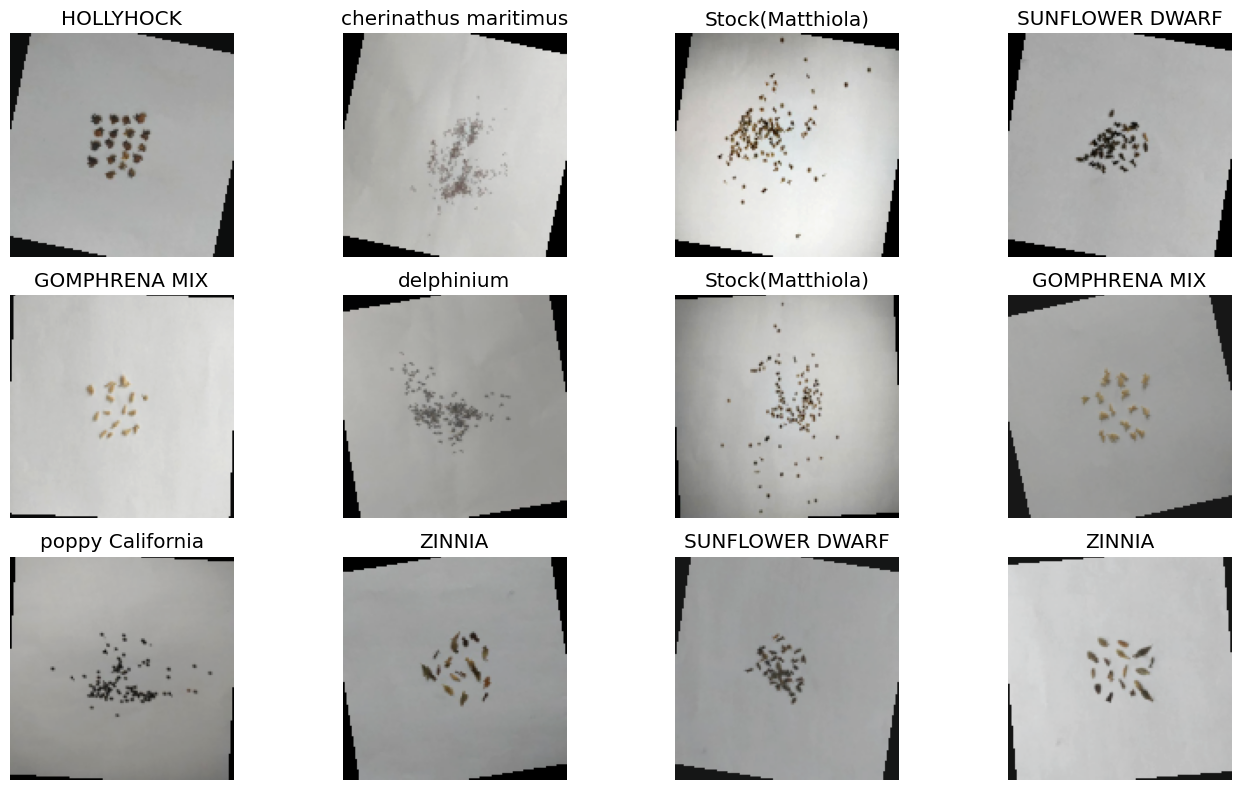

In [58]:
import matplotlib.pyplot as plt

class_names = base_dataset.classes

plt.figure(figsize=(14,8))

for i in range(12):

    plt.subplot(3,4,i+1)

    image = images[i].permute(1,2,0)

    image = image.numpy()

    image = image * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])

    image = np.clip(image,0,1)

    plt.imshow(image)

    plt.title(class_names[labels[i]])

    plt.axis("off")

plt.tight_layout()

plt.show()

# 8. Custom CNN Architecture

A custom Convolutional Neural Network (CNN) is designed for multi-class flower seed classification. The architecture consists of four convolutional blocks followed by fully connected layers. Batch Normalization and Dropout are incorporated to improve convergence and reduce overfitting.

In [59]:
# ============================================
# Custom CNN Model
# ============================================

import torch
import torch.nn as nn

class FlowerSeedCNN(nn.Module):

    def __init__(self, num_classes=40):

        super(FlowerSeedCNN, self).__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(256 * 8 * 8, 512),

            nn.ReLU(inplace=True),

            nn.Dropout(0.5),

            nn.Linear(512, num_classes)

        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [60]:
NUM_CLASSES = len(base_dataset.classes)

model = FlowerSeedCNN(num_classes=NUM_CLASSES)

model = model.to(device)

print(model)

FlowerSeedCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1

In [61]:
# ============================================
# Count Trainable Parameters
# ============================================

total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("="*50)

print(f"Total Parameters      : {total_params:,}")

print(f"Trainable Parameters  : {trainable_params:,}")

print("="*50)

Total Parameters      : 8,799,016
Trainable Parameters  : 8,799,016


In [62]:
!pip -q install torchinfo

In [63]:
from torchinfo import summary

summary(
    model,
    input_size=(32, 3, 128, 128),
    col_names=[
        "input_size",
        "output_size",
        "num_params",
        "trainable"
    ]
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
FlowerSeedCNN                            [32, 3, 128, 128]         [32, 40]                  --                        True
├─Sequential: 1-1                        [32, 3, 128, 128]         [32, 256, 8, 8]           --                        True
│    └─Conv2d: 2-1                       [32, 3, 128, 128]         [32, 32, 128, 128]        896                       True
│    └─BatchNorm2d: 2-2                  [32, 32, 128, 128]        [32, 32, 128, 128]        64                        True
│    └─ReLU: 2-3                         [32, 32, 128, 128]        [32, 32, 128, 128]        --                        --
│    └─MaxPool2d: 2-4                    [32, 32, 128, 128]        [32, 32, 64, 64]          --                        --
│    └─Conv2d: 2-5                       [32, 32, 64, 64]          [32, 64, 64, 64]          18,496                    True
│    └─

# 9. Hyperparameter Configuration

The following hyperparameters are used during training.

| Hyperparameter | Value |
|---------------|------|
| Optimizer | Adam |
| Learning Rate | 0.001 |
| Batch Size | 32 |
| Epochs | 20 |
| Loss Function | CrossEntropyLoss |

In [64]:
# ============================================
# Hyperparameters
# ============================================

LEARNING_RATE = 0.001
EPOCHS = 20

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Loss Function :", criterion)

print("Optimizer :", optimizer)

Loss Function : CrossEntropyLoss()
Optimizer : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [65]:
images, labels = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print("Input Shape :", images.shape)

print("Output Shape :", outputs.shape)

Input Shape : torch.Size([32, 3, 128, 128])
Output Shape : torch.Size([32, 40])


# 10. Model Training

The model is trained using the Adam optimizer and CrossEntropyLoss. After every epoch, the model is evaluated on the validation dataset. The model with the highest validation accuracy is automatically saved.

In [66]:
# ============================================
# Training History
# ============================================

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_accuracy = 0.0

best_model_weights = None

In [67]:
# ============================================
# Training Function
# ============================================

def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)

    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

In [68]:
# ============================================
# Validation Function
# ============================================

def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)

    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

In [69]:
# ============================================
# Start Training
# ============================================

import time
import copy

start_time = time.time()

print("=" * 80)
print("Training Started...")
print("=" * 80)

for epoch in range(EPOCHS):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = validate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    # Save best model
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        best_model_weights = copy.deepcopy(model.state_dict())

        torch.save(
            best_model_weights,
            "best_flower_seed_model.pth"
        )

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2f}%"
    )

training_time = time.time() - start_time

print("\nTraining Finished!")

print(f"Best Validation Accuracy : {best_val_accuracy:.2f}%")

print(f"Training Time : {training_time/60:.2f} minutes")

Training Started...
Epoch [01/20] | Train Loss: 3.4424 | Train Acc: 9.08% | Val Loss: 2.5810 | Val Acc: 19.08%
Epoch [02/20] | Train Loss: 2.7445 | Train Acc: 16.22% | Val Loss: 2.0359 | Val Acc: 34.52%
Epoch [03/20] | Train Loss: 2.4037 | Train Acc: 22.46% | Val Loss: 1.6861 | Val Acc: 45.76%
Epoch [04/20] | Train Loss: 2.2066 | Train Acc: 26.20% | Val Loss: 1.4108 | Val Acc: 50.67%
Epoch [05/20] | Train Loss: 1.9944 | Train Acc: 31.77% | Val Loss: 1.0353 | Val Acc: 67.01%
Epoch [06/20] | Train Loss: 1.8307 | Train Acc: 36.40% | Val Loss: 1.1300 | Val Acc: 62.67%
Epoch [07/20] | Train Loss: 1.7106 | Train Acc: 39.50% | Val Loss: 0.7941 | Val Acc: 76.20%
Epoch [08/20] | Train Loss: 1.5730 | Train Acc: 43.78% | Val Loss: 1.0326 | Val Acc: 61.84%
Epoch [09/20] | Train Loss: 1.4580 | Train Acc: 46.62% | Val Loss: 0.8194 | Val Acc: 71.22%
Epoch [10/20] | Train Loss: 1.3409 | Train Acc: 50.64% | Val Loss: 0.6860 | Val Acc: 72.88%
Epoch [11/20] | Train Loss: 1.2408 | Train Acc: 54.47% | Val 

# 11. Model Evaluation

The best-performing model is evaluated on the unseen test dataset using multiple evaluation metrics, including Accuracy, Precision, Recall, F1-score, Classification Report, and Confusion Matrix.

In [70]:
!pip -q install scikit-learn

In [71]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import numpy as np

In [72]:
model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

print("Testing Completed!")

Testing Completed!


In [73]:
accuracy = accuracy_score(all_labels, all_predictions)

precision = precision_score(
    all_labels,
    all_predictions,
    average='weighted',
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    average='weighted',
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average='weighted',
    zero_division=0
)

print("="*50)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print("="*50)

Accuracy : 0.9567
Precision: 0.9642
Recall   : 0.9567
F1 Score : 0.9552


In [74]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=base_dataset.classes,
        zero_division=0
    )
)

                       precision    recall  f1-score   support

      AFRICAN MARGOLD       0.97      1.00      0.99        38
              ALYSSUM       0.84      1.00      0.91        43
          Acroclineum       1.00      1.00      1.00        34
            CALENDULA       1.00      1.00      1.00        45
        CHRYSANTHEMUM       0.95      1.00      0.98        40
            COREOPSIS       0.95      0.97      0.96        38
        DIMORPHOTHECA       0.97      0.91      0.94        32
               Dahlia       1.00      1.00      1.00        42
        GOMPHRENA MIX       1.00      1.00      1.00        40
           GYPSOPHILA       1.00      0.80      0.89        30
           Gaillardia       1.00      1.00      1.00        31
          HELICHRYSUM       0.96      0.89      0.92        27
            HOLLYHOCK       0.96      0.96      0.96        47
           Ice Flower       0.68      1.00      0.81        48
               Lupins       1.00      1.00      1.00  

In [75]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm.shape)

(40, 40)


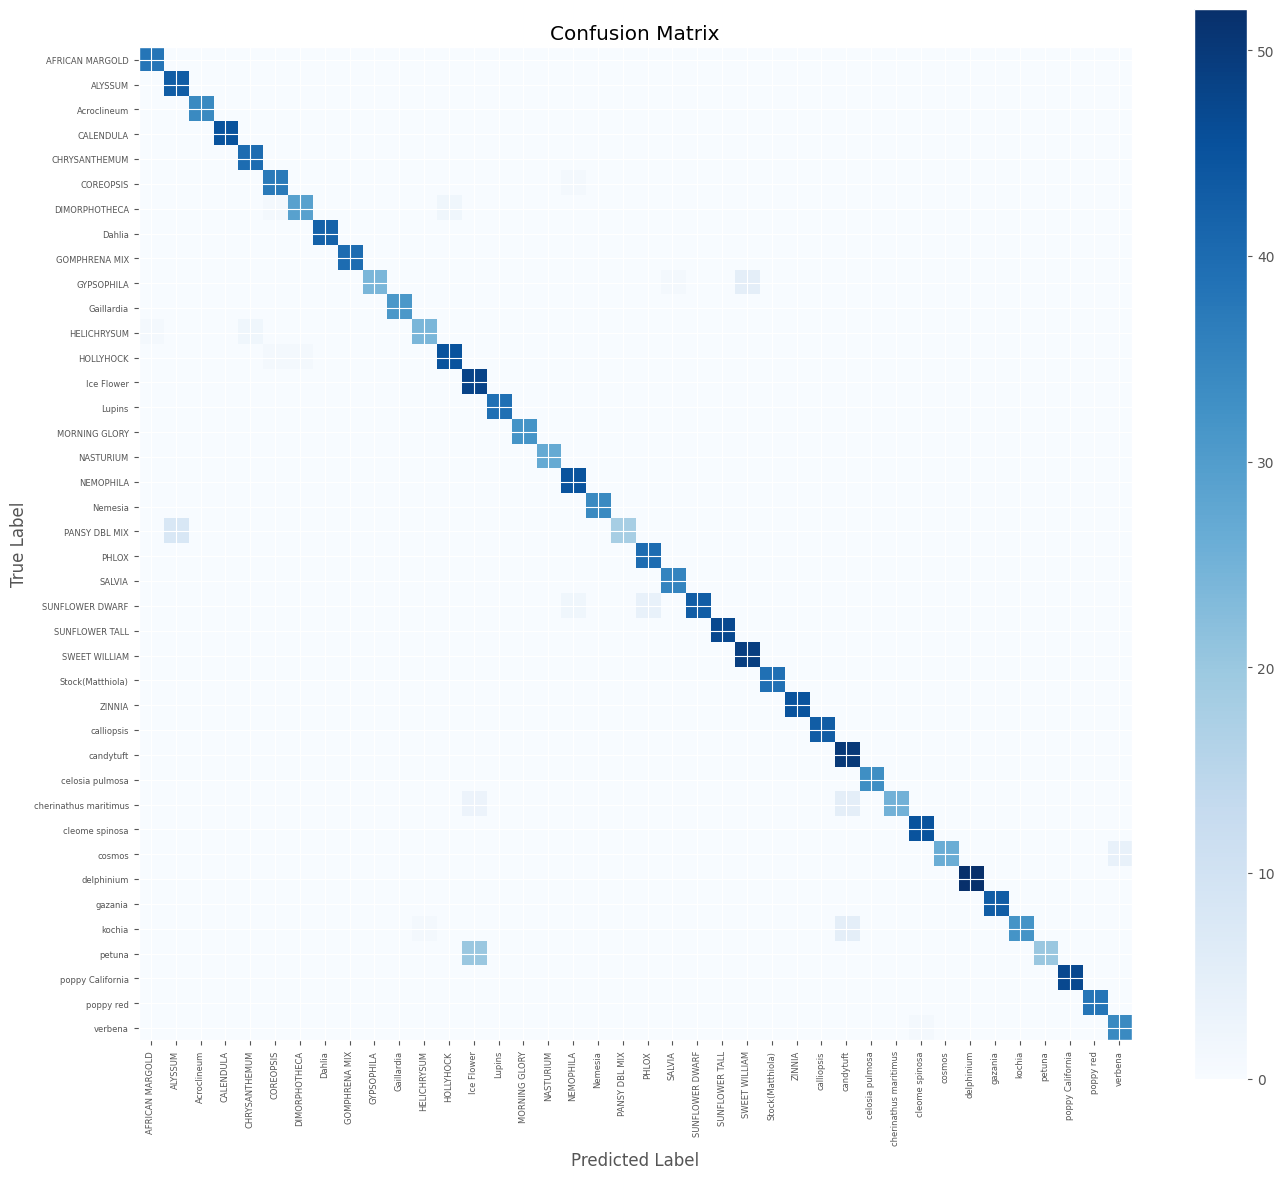

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,12))

plt.imshow(cm, interpolation='nearest', cmap='Blues')

plt.title("Confusion Matrix")

plt.colorbar()

tick_marks = np.arange(len(base_dataset.classes))

plt.xticks(
    tick_marks,
    base_dataset.classes,
    rotation=90,
    fontsize=6
)

plt.yticks(
    tick_marks,
    base_dataset.classes,
    fontsize=6
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.tight_layout()

plt.show()

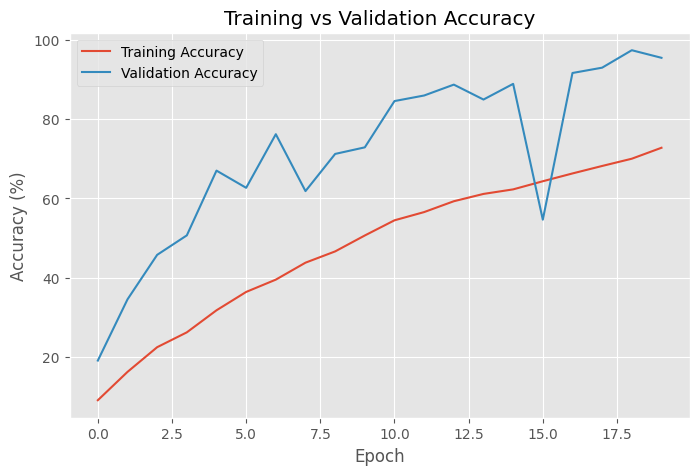

In [77]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="Training Accuracy")

plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

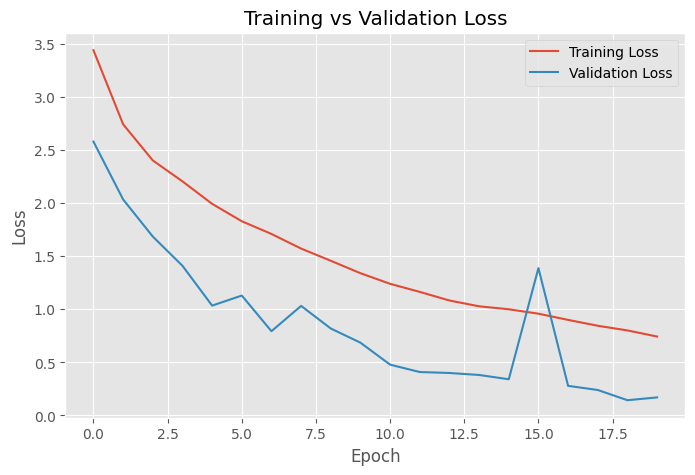

In [78]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss")

plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

In [79]:
class_correct = np.zeros(len(base_dataset.classes))
class_total = np.zeros(len(base_dataset.classes))

for true_label, pred_label in zip(all_labels, all_predictions):

    class_total[true_label] += 1

    if true_label == pred_label:
        class_correct[true_label] += 1

class_accuracy = 100 * class_correct / class_total

for idx, class_name in enumerate(base_dataset.classes):

    print(f"{class_name:25s}: {class_accuracy[idx]:6.2f}%")

AFRICAN MARGOLD          : 100.00%
ALYSSUM                  : 100.00%
Acroclineum              : 100.00%
CALENDULA                : 100.00%
CHRYSANTHEMUM            : 100.00%
COREOPSIS                :  97.37%
DIMORPHOTHECA            :  90.62%
Dahlia                   : 100.00%
GOMPHRENA MIX            : 100.00%
GYPSOPHILA               :  80.00%
Gaillardia               : 100.00%
HELICHRYSUM              :  88.89%
HOLLYHOCK                :  95.74%
Ice Flower               : 100.00%
Lupins                   : 100.00%
MORNING GLORY            : 100.00%
NASTURIUM                : 100.00%
NEMOPHILA                : 100.00%
Nemesia                  : 100.00%
PANSY DBL MIX            :  69.23%
PHLOX                    : 100.00%
SALVIA                   : 100.00%
SUNFLOWER DWARF          :  87.76%
SUNFLOWER TALL           : 100.00%
SWEET WILLIAM            : 100.00%
Stock(Matthiola)         : 100.00%
ZINNIA                   : 100.00%
calliopsis               : 100.00%
candytuft           

In [80]:
best_index = np.argmax(class_accuracy)
worst_index = np.argmin(class_accuracy)

print("="*50)

print("Best Performing Class")
print(base_dataset.classes[best_index])
print(f"{class_accuracy[best_index]:.2f}%")

print()

print("Worst Performing Class")
print(base_dataset.classes[worst_index])
print(f"{class_accuracy[worst_index]:.2f}%")

print("="*50)

Best Performing Class
AFRICAN MARGOLD
100.00%

Worst Performing Class
petuna
50.00%


In [81]:
save_path = "/content/drive/MyDrive/CVPR_Assignment/best_flower_seed_model.pth"

torch.save(model.state_dict(), save_path)

print(f"Model saved to:\n{save_path}")

Model saved to:
/content/drive/MyDrive/CVPR_Assignment/best_flower_seed_model.pth


# 12. Conclusion

A custom Convolutional Neural Network (CNN) was successfully developed and trained for multi-class flower seed classification. The dataset was preprocessed using resizing, normalization, and data augmentation techniques. The model was evaluated using Accuracy, Precision, Recall, F1-score, Classification Report, and Confusion Matrix.

The learning curves indicated the model's training behavior, while the confusion matrix and per-class analysis highlighted strengths and areas where classification errors occurred. Overall, the custom CNN demonstrated effective performance on the flower seed dataset.

## Future Improvements

- Increase the number of training epochs.
- Perform hyperparameter tuning.
- Experiment with deeper CNN architectures.
- Use learning rate scheduling.
- Apply additional data augmentation techniques.